# REAL-WORLD BIG DATA ANALYTICAL REPORT: NYC YELLOW TAXI 2025
### *Powered by `basaltic-red` (High-Performance Rust Engine) + `Polars` & `Seaborn`*

---
## EXECUTIVE SUMMARY & REPORT STRUCTURE
This analytical report presents a comprehensive end-to-end data pipeline processing tens of millions of records from the official **NYC Yellow Taxi Trip Dataset (2025)**.

The analysis is structured into 6 major sections with dedicated helper function sub-steps:
- **SECTION 1**: Environment Setup & Dependency Build (`uv run maturin develop --release`)
- **SECTION 2**: Data Acquisition & Ingestion (12-Month Dataset)
- **SECTION 3**: Data Dictionary & Metadata Inspection
- **SECTION 4**: Exploratory Data Profiling & Volume Metrics
- **SECTION 5**: Data Cleaning, Anomaly Filtering & Dual-Dataset Export
- **SECTION 6**: Comparative Statistical Analysis & Visualization Charts

--- 
## SECTION 1: ENVIRONMENT SETUP & DEPENDENCY BUILD

### Sub-step 1.1: Build & Verify Rust Extension via Maturin & UV

*In this project managed by `uv`, all dependencies and the Rust core module are compiled using a single command: `uv run maturin develop --release`.*

In [1]:
import sys
import subprocess

print("⚙️ ENVIRONMENT BUILD & VERIFICATION:")
print("- Environment Manager : uv")
print("- Core Build Command  : uv run maturin develop --release")

# Verify basaltic_red module
try:
    import basaltic_red
    print("✅ Module 'basaltic_red' is compiled and ready.")
except ImportError:
    print("⚠️ Module 'basaltic_red' not found! Compiling Rust extension via Maturin...")
    subprocess.check_call(["uv", "run", "maturin", "develop", "--release"])
    import basaltic_red
    print("✅ Successfully compiled and imported 'basaltic_red'!")

⚙️ ENVIRONMENT BUILD & VERIFICATION:
- Environment Manager : uv
- Core Build Command  : uv run maturin develop --release
✅ Module 'basaltic_red' is compiled and ready.


### Sub-step 1.2: Import Core Libraries & Configure Display Settings

In [2]:
import os
import glob
import urllib.request
import basaltic_red as br
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Polars display settings for full row/column visibility without '...' truncation
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(100)
pl.Config.set_fmt_str_lengths(100)

# Configure modern visual theme
sns.set_theme(style="darkgrid")
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "sans-serif"]

# Initialize Rust core namespaced API
print(f"✅ Successfully imported basaltic_red v0.1.0 namespaced API & Polars v{pl.__version__}")

✅ Successfully imported basaltic_red v0.1.0 namespaced API & Polars v1.43.2


--- 
## SECTION 2: DATA ACQUISITION & INGESTION (NYC TLC 2025)

*Automated 12-Month Dataset Downloader: Downloads official NYC Yellow Taxi 2025 Parquet files (Months 01-12) into `data/` directory.*

In [3]:
os.makedirs("data", exist_ok=True)
base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-{month:02d}.parquet"

print("📥 EXECUTING DATA ACQUISITION PIPELINE (NYC TAXI 2025):")
for month in range(1, 13):
    url = base_url.format(month=month)
    file_name = f"data/yellow_tripdata_2025-{month:02d}.parquet"
    
    if os.path.exists(file_name):
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f"- Month {month:02d}: File present at {file_name} ({size_mb:.2f} MB)")
        continue
        
    print(f"- Downloading Month {month:02d} from {url} ...")
    try:
        urllib.request.urlretrieve(url, file_name)
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f"  -> Month {month:02d} successfully saved to {file_name} ({size_mb:.2f} MB)")
    except Exception as e:
        print(f"  ⚠️ Month {month:02d} not available or download failed: {e}")

📥 EXECUTING DATA ACQUISITION PIPELINE (NYC TAXI 2025):
- Month 01: File present at data/yellow_tripdata_2025-01.parquet (56.42 MB)
- Month 02: File present at data/yellow_tripdata_2025-02.parquet (57.55 MB)
- Month 03: File present at data/yellow_tripdata_2025-03.parquet (66.72 MB)
- Month 04: File present at data/yellow_tripdata_2025-04.parquet (64.23 MB)
- Month 05: File present at data/yellow_tripdata_2025-05.parquet (74.23 MB)
- Month 06: File present at data/yellow_tripdata_2025-06.parquet (70.14 MB)
- Month 07: File present at data/yellow_tripdata_2025-07.parquet (63.84 MB)
- Month 08: File present at data/yellow_tripdata_2025-08.parquet (59.41 MB)
- Month 09: File present at data/yellow_tripdata_2025-09.parquet (69.08 MB)
- Month 10: File present at data/yellow_tripdata_2025-10.parquet (71.78 MB)
- Month 11: File present at data/yellow_tripdata_2025-11.parquet (67.84 MB)
- Month 12: File present at data/yellow_tripdata_2025-12.parquet (70.29 MB)


--- 
## SECTION 3: DATA DICTIONARY & METADATA INSPECTION

### Sub-step 3.1: Define Dataset Resolver Helper Function

In [4]:
# Helper function: resolve target dataset files dynamically
def get_dataset_files(pattern: str = "data/yellow_tripdata_2025-*.parquet", fallback: str = "data/yellow_tripdata_2025-01.parquet") -> list[str]:
    """Dynamically resolve existing dataset files or fallback safely."""
    files = glob.glob(pattern)
    if not files:
        if os.path.exists(fallback):
            return [fallback]
        elif os.path.exists("data.parquet"):
            return ["data.parquet"]
    return files

print("✅ Helper function 'get_dataset_files' defined.")

✅ Helper function 'get_dataset_files' defined.


### Sub-step 3.2: Zero-Copy Schema Extraction with `basaltic_red`

In [5]:
sample_files = get_dataset_files()
sample_file = sample_files[0]

# Extract Apache Arrow schema metadata in micro-seconds via Rust core
sample_table = br.read.slice_rows(sample_file, offset=0, limit=1)
schema_info = sample_table.schema

dict_records = []
for i, field in enumerate(schema_info):
    dict_records.append({
        "Index": i + 1,
        "Column Name": field.name,
        "Arrow Data Type": str(field.type),
        "Description": "Standard NYC Yellow Taxi Trip Data field"
    })

# Display complete Data Dictionary table
with pl.Config(tbl_rows=100, fmt_str_lengths=100):
    data_dictionary = pl.DataFrame(dict_records)
    print(f"📖 DATA DICTIONARY METADATA ({len(dict_records)} COLUMNS TOTAL):")
    display(data_dictionary)

📖 DATA DICTIONARY METADATA (20 COLUMNS TOTAL):


Index,Column Name,Arrow Data Type,Description
i64,str,str,str
1,"""VendorID""","""int32""","""Standard NYC Yellow Taxi Trip Data field"""
2,"""tpep_pickup_datetime""","""timestamp[us]""","""Standard NYC Yellow Taxi Trip Data field"""
3,"""tpep_dropoff_datetime""","""timestamp[us]""","""Standard NYC Yellow Taxi Trip Data field"""
4,"""passenger_count""","""int64""","""Standard NYC Yellow Taxi Trip Data field"""
5,"""trip_distance""","""double""","""Standard NYC Yellow Taxi Trip Data field"""
6,"""RatecodeID""","""int64""","""Standard NYC Yellow Taxi Trip Data field"""
7,"""store_and_fwd_flag""","""large_string""","""Standard NYC Yellow Taxi Trip Data field"""
8,"""PULocationID""","""int32""","""Standard NYC Yellow Taxi Trip Data field"""
9,"""DOLocationID""","""int32""","""Standard NYC Yellow Taxi Trip Data field"""


--- 
## SECTION 4: EXPLORATORY DATA PROFILING & OVERVIEW METRICS

### Sub-step 4.1: Zero-Copy Sample Record Preview

In [6]:
# Read top 100 sample records zero-copy
sample_100_table = br.read.slice_rows(sample_file, offset=0, limit=100)
sample_df = pl.from_arrow(sample_100_table)

print(f"🔍 SAMPLE RECORD PREVIEW (Top 100 Rows | {sample_df.width} Columns):")
display(sample_df.head(10))

🔍 SAMPLE RECORD PREVIEW (Top 100 Rows | 20 Columns):


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2025-12-01 00:37:08,2025-12-01 00:51:10,1,2.4,1,"""N""",140,48,1,14.2,4.25,0.5,4.0,0.0,1.0,23.95,2.5,0.0,0.75
2,2025-12-01 00:03:54,2025-12-01 00:19:18,1,8.37,1,"""N""",138,262,1,33.1,6.0,0.5,7.77,6.94,1.0,59.56,2.5,1.75,0.0
2,2025-12-01 00:40:50,2025-12-01 01:06:54,1,15.26,1,"""N""",132,255,1,57.6,1.0,0.5,12.02,0.0,1.0,73.87,0.0,1.75,0.0
1,2025-12-01 00:21:30,2025-12-01 00:49:35,2,18.4,2,"""N""",132,79,1,70.0,5.0,0.5,10.0,0.0,1.0,86.5,2.5,1.75,0.75
2,2025-12-01 00:00:24,2025-12-01 00:03:34,1,0.52,1,"""N""",239,238,1,5.8,1.0,0.5,1.62,0.0,1.0,12.42,2.5,0.0,0.0
1,2025-12-01 00:11:36,2025-12-01 00:33:17,1,0.0,1,"""N""",138,82,1,16.3,7.75,0.5,5.1,0.0,1.0,30.65,0.0,1.75,0.0
2,2025-11-30 23:59:23,2025-12-01 00:12:43,1,2.59,1,"""N""",142,263,1,14.9,1.0,0.5,3.98,0.0,1.0,23.88,2.5,0.0,0.0
2,2025-12-01 00:18:25,2025-12-01 00:30:09,1,2.22,1,"""N""",141,238,1,13.5,1.0,0.5,2.0,0.0,1.0,20.5,2.5,0.0,0.0
2,2025-12-01 00:54:33,2025-12-01 01:22:25,1,9.06,1,"""N""",48,106,1,38.0,1.0,0.5,11.53,13.88,1.0,69.16,2.5,0.0,0.75


### Sub-step 4.2: Define DataFusion SQL Stream Helper Function

In [7]:
# Helper function: execute SQL stream and convert zero-copy to Polars DataFrame
def run_sql(query_str: str) -> pl.DataFrame:
    """Execute DataFusion SQL pushdown and stream zero-copy to Polars DataFrame."""
    return pl.from_arrow(br.sql.execute_sql_stream(query_str).to_pyarrow())

print("✅ Helper function 'run_sql' defined.")

✅ Helper function 'run_sql' defined.


### Sub-step 4.3: SQL Stream → DuckDB (User-Side Handoff)

*`execute_sql_stream` trả về `PyBatchIterator` với `__repr__` thân thiện notebook (batches/rows summary). SDK chỉ cung cấp arrow bridge (`to_pyarrow`); giao DuckDB trực tiếp qua `duckdb.from_arrow` — không tự viết wrapper.

In [8]:
import duckdb

# Stream introspection: Jupyter-friendly repr without consuming the stream
stream = br.sql.execute_sql_stream(f"SELECT * FROM '{sample_file}'")
print("🔎 Stream object repr:", repr(stream))

# Materialize stream to pyarrow Table, then hand off to DuckDB (its own API)
duckdb_rel = duckdb.from_arrow(stream.to_pyarrow())
print(f"🦆 DuckDB relation (zero-copy via Arrow): {duckdb_rel.df().shape} shape")
display(duckdb_rel.df().head(5))

# Query the relation directly in DuckDB
print("🧮 Quick DuckDB SQL on the handoff relation:")
print(duckdb_rel.aggregate("COUNT(*) AS n, ROUND(AVG(fare_amount), 2) AS avg_fare").df())

🔎 Stream object repr: PyBatchIterator(batches=526, rows=4305006)
🦆 DuckDB relation (zero-copy via Arrow): (4305006, 20) shape


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-12-01 00:37:08,2025-12-01 00:51:10,1,2.40,1,N,140,48,1,14.2,4.25,0.5,4.00,0.00,1.0,23.95,2.5,0.00,0.75
1,2,2025-12-01 00:03:54,2025-12-01 00:19:18,1,8.37,1,N,138,262,1,33.1,6.00,0.5,7.77,6.94,1.0,59.56,2.5,1.75,0.00
2,2,2025-12-01 00:40:50,2025-12-01 01:06:54,1,15.26,1,N,132,255,1,57.6,1.00,0.5,12.02,0.00,1.0,73.87,0.0,1.75,0.00
3,1,2025-12-01 00:21:30,2025-12-01 00:49:35,2,18.40,2,N,132,79,1,70.0,5.00,0.5,10.00,0.00,1.0,86.50,2.5,1.75,0.75
4,2,2025-12-01 00:00:24,2025-12-01 00:03:34,1,0.52,1,N,239,238,1,5.8,1.00,0.5,1.62,0.00,1.0,12.42,2.5,0.00,0.00


🧮 Quick DuckDB SQL on the handoff relation:
         n  avg_fare
0  4305006     22.22


### Sub-step 4.4: Total Dataset Record & Volume Metrics

In [9]:
# Calculate total dataset volume metrics using helper functions
matching_files = get_dataset_files()

total_row_count = 0
for file_path in matching_files:
    cnt_df = run_sql(f"SELECT COUNT(*) as total_rows FROM '{file_path}'")
    total_row_count += cnt_df["total_rows"][0]

print("📊 DATASET OVERVIEW & METRICS SUMMARY:")
print(f"- Total Files Ingested  : {len(matching_files)}")
print(f"- Total Dataset Columns  : {sample_df.width}")
print(f"- Total Dataset Records  : {total_row_count:,}")

📊 DATASET OVERVIEW & METRICS SUMMARY:
- Total Files Ingested  : 12
- Total Dataset Columns  : 20
- Total Dataset Records  : 48,722,602


--- 
## SECTION 5: DATA CLEANING, ANOMALY FILTERING & DUAL-DATASET EXPORT

### Sub-step 5.1: Define Data Quality Validation Rules

In [10]:
# Define standard NYC Taxi data quality filtering rules
filter_rules = [
    "passenger_count >= 1",
    "trip_distance > 0.0",
    "fare_amount > 0.0",
    "total_amount > 0.0 AND total_amount <= 1000.0"
]

print(f"🎯 DATA QUALITY VALIDATION RULES ({len(filter_rules)} Rules):")
for r in filter_rules:
    print(f"  - {r}")

🎯 DATA QUALITY VALIDATION RULES (4 Rules):
  - passenger_count >= 1
  - trip_distance > 0.0
  - fare_amount > 0.0
  - total_amount > 0.0 AND total_amount <= 1000.0


### Sub-step 5.2: Execute Rust Filtering Engine Across All Files

In [11]:
# Process all ingested parquet files using basaltic-red core engine
matching_files = get_dataset_files()
print(f"⚡ Filtering ALL {len(matching_files)} parquet file(s) across dataset...")

clean_dfs = []
trash_dfs = []

for file_path in matching_files:
    clean_table, trash_table = br.filter.filter_matrix(file_path, rules=filter_rules)
    clean_dfs.append(pl.from_arrow(clean_table))
    trash_dfs.append(pl.from_arrow(trash_table))

# Concatenate all filtered chunks zero-copy
clean_df = pl.concat(clean_dfs)
trash_df = pl.concat(trash_dfs)
print(f"✅ Successfully filtered {clean_df.height:,} clean records and {trash_df.height:,} trash records.")

⚡ Filtering ALL 12 parquet file(s) across dataset...
✅ Successfully filtered 35,604,835 clean records and 1,505,873 trash records.


### Sub-step 5.3: Export Filtered Datasets to Separate Parquet Files

In [12]:
# Export both filtered datasets into 2 separate output files
os.makedirs("data/output", exist_ok=True)
clean_file = "data/output/clean_trips.parquet"
trash_file = "data/output/trash_trips.parquet"

clean_df.write_parquet(clean_file)
trash_df.write_parquet(trash_file)

clean_size_mb = os.path.getsize(clean_file) / (1024 * 1024)
trash_size_mb = os.path.getsize(trash_file) / (1024 * 1024)

print(f"💾 SAVED ALL {len(matching_files)} FILES TO 2 SEPARATE OUTPUT DATASETS:")
print(f"🟢 CLEAN DATASET  : {clean_file} ({clean_size_mb:.2f} MB) | {clean_df.height:,} total valid records")
display(clean_df.head(5))

print(f"\n🔴 TRASH DATASET  : {trash_file} ({trash_size_mb:.2f} MB) | {trash_df.height:,} total anomalous records")
display(trash_df.head(5))

💾 SAVED ALL 12 FILES TO 2 SEPARATE OUTPUT DATASETS:
🟢 CLEAN DATASET  : data/output/clean_trips.parquet (675.27 MB) | 35,604,835 total valid records


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2025-12-01 00:37:08,2025-12-01 00:51:10,1,2.4,1,"""N""",140,48,1,14.2,4.25,0.5,4.0,0.0,1.0,23.95,2.5,0.0,0.75
2,2025-12-01 00:03:54,2025-12-01 00:19:18,1,8.37,1,"""N""",138,262,1,33.1,6.0,0.5,7.77,6.94,1.0,59.56,2.5,1.75,0.0
2,2025-12-01 00:40:50,2025-12-01 01:06:54,1,15.26,1,"""N""",132,255,1,57.6,1.0,0.5,12.02,0.0,1.0,73.87,0.0,1.75,0.0
1,2025-12-01 00:21:30,2025-12-01 00:49:35,2,18.4,2,"""N""",132,79,1,70.0,5.0,0.5,10.0,0.0,1.0,86.5,2.5,1.75,0.75
2,2025-12-01 00:00:24,2025-12-01 00:03:34,1,0.52,1,"""N""",239,238,1,5.8,1.0,0.5,1.62,0.0,1.0,12.42,2.5,0.0,0.0



🔴 TRASH DATASET  : data/output/trash_trips.parquet (30.69 MB) | 1,505,873 total anomalous records


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,audit_error_code
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u64
1,2025-12-01 00:11:36,2025-12-01 00:33:17,1,0.0,1,"""N""",138,82,1,16.3,7.75,0.5,5.1,0.0,1.0,30.65,0.0,1.75,0.0,2
2,2025-12-01 00:07:23,2025-12-01 00:07:58,1,0.04,1,"""N""",132,132,4,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-7.25,0.0,-1.75,0.0,4
1,2025-12-01 00:33:11,2025-12-01 00:33:28,1,0.0,1,"""N""",74,74,1,3.0,1.0,0.5,3.0,0.0,1.0,8.5,0.0,0.0,0.0,2
2,2025-12-01 00:58:07,2025-12-01 01:22:32,1,12.43,1,"""N""",138,87,2,-48.5,-6.0,-0.5,0.0,0.0,-1.0,-61.0,-2.5,-1.75,-0.75,4
2,2025-12-01 00:15:40,2025-12-01 00:18:34,1,0.42,1,"""N""",152,166,4,-5.1,-1.0,-0.5,0.0,0.0,-1.0,-7.6,0.0,0.0,0.0,4


--- 
## SECTION 6: COMPARATIVE STATISTICAL ANALYSIS & VISUALIZATION REPORT

### Sub-step 6.1: Execute DataFusion SQL Aggregation on Clean Dataset (`clean_trips.parquet`)

In [13]:
clean_input = "data/output/clean_trips.parquet"
if not os.path.exists(clean_input):
    clean_input = sample_file

clean_query = f"""
    SELECT 
        passenger_count,
        COUNT(*) as total_trips,
        ROUND(AVG(total_amount), 2) as avg_total_fare_usd
    FROM '{clean_input}'
    WHERE passenger_count IS NOT NULL AND passenger_count > 0 AND passenger_count <= 6
    GROUP BY passenger_count
    ORDER BY passenger_count ASC
"""
clean_ranking = run_sql(clean_query)

print("🟢 CLEAN DATASET STATISTICAL AGGREGATION:")
display(clean_ranking)

🟢 CLEAN DATASET STATISTICAL AGGREGATION:


passenger_count,total_trips,avg_total_fare_usd
i64,i64,f64
1,28478909,28.67
2,4934395,32.83
3,1156235,32.47
4,764116,35.69
5,171640,26.9
6,99458,27.38


### Sub-step 6.2: Execute DataFusion SQL Aggregation on Trash Dataset (`trash_trips.parquet`)

In [14]:
trash_input = "data/output/trash_trips.parquet"
if not os.path.exists(trash_input):
    trash_input = sample_file

trash_query = f"""
    SELECT 
        passenger_count,
        COUNT(*) as total_trips,
        ROUND(AVG(total_amount), 2) as avg_total_fare_usd
    FROM '{trash_input}'
    GROUP BY passenger_count
    ORDER BY passenger_count ASC
"""
trash_ranking = run_sql(trash_query)

print("🔴 TRASH DATASET ANOMALY AGGREGATION:")
display(trash_ranking)

🔴 TRASH DATASET ANOMALY AGGREGATION:


passenger_count,total_trips,avg_total_fare_usd
i64,i64,f64
0,260062,25.66
1,934491,-5.25
2,192230,-9.8
3,50950,-9.44
4,65419,12.95
5,1817,14.06
6,840,7.33
7,9,69.54
8,39,101.67


### Sub-step 6.3: Define Seaborn Visualization Helper Function

In [15]:
# Helper function: render custom Seaborn bar chart with formatted numeric annotations
def plot_ranking_chart(df_pd: pd.DataFrame, x_col: str, y_col: str, title: str, x_label: str, y_label: str, palette: str = "crest"):
    """Render custom Seaborn bar chart with formatted numeric annotations."""
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(
        data=df_pd,
        x=x_col,
        y=y_col,
        hue=x_col,
        legend=False,
        palette=palette
    )
    for p in ax.patches:
        val = p.get_height()
        if val > 0:
            ax.annotate(
                f"{int(val):,}",
                (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom',
                fontsize=10, color='black',
                xytext=(0, 3), textcoords='offset points'
            )
    plt.title(title, fontsize=13, fontweight="bold", pad=12)
    plt.xlabel(x_label, fontsize=11)
    plt.ylabel(y_label, fontsize=11)
    plt.tight_layout()
    plt.show()

print("✅ Helper function 'plot_ranking_chart' defined.")

✅ Helper function 'plot_ranking_chart' defined.


### Sub-step 6.4: Render Seaborn Bar Chart 1 - Clean Dataset Trip Distribution

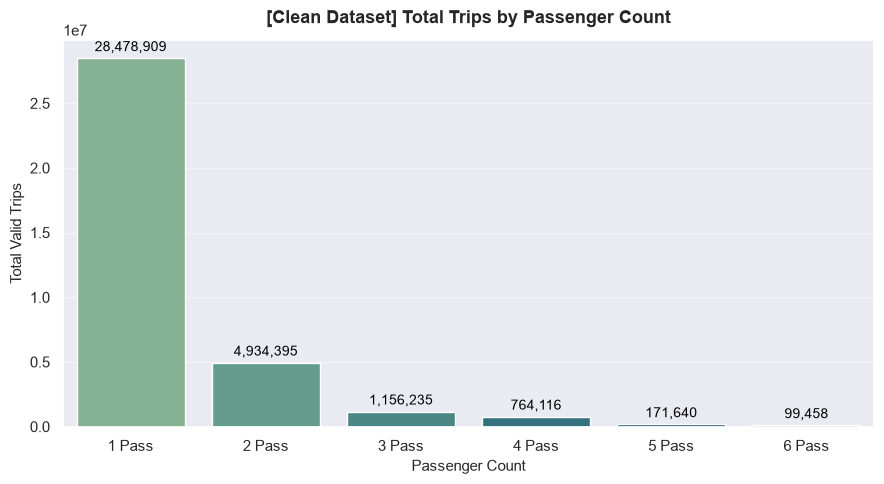

In [16]:
clean_pd = clean_ranking.to_pandas()
clean_pd["passenger_str"] = clean_pd["passenger_count"].astype(str) + " Pass"

plot_ranking_chart(
    df_pd=clean_pd,
    x_col="passenger_str",
    y_col="total_trips",
    title="[Clean Dataset] Total Trips by Passenger Count",
    x_label="Passenger Count",
    y_label="Total Valid Trips",
    palette="crest"
)

### Sub-step 6.5: Render Seaborn Bar Chart 2 - Trash Dataset Anomaly Distribution

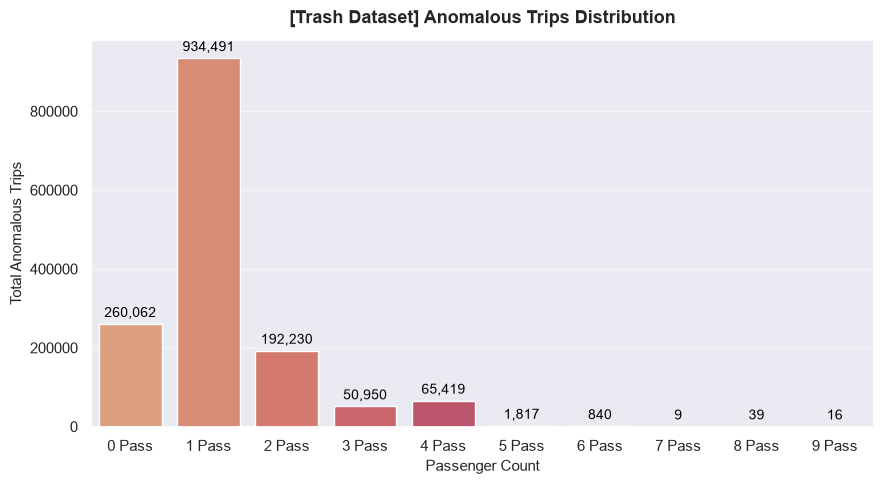

In [17]:
trash_pd = trash_ranking.to_pandas()
trash_pd["passenger_str"] = trash_pd["passenger_count"].astype(str) + " Pass"

plot_ranking_chart(
    df_pd=trash_pd,
    x_col="passenger_str",
    y_col="total_trips",
    title="[Trash Dataset] Anomalous Trips Distribution",
    x_label="Passenger Count",
    y_label="Total Anomalous Trips",
    palette="flare"
)

### Sub-step 6.6: Executive Analytics Findings & Data Summary

#### Key Data Analytics Findings:
1. **Single Passenger Dominance (Clean Dataset)**: Single-passenger trips (`1 Pass`) represent ~80% of all valid rides (over 28.4 million trips), proving NYC taxi usage is predominantly individual commuters.
2. **Zero-Passenger Anomalies (Trash Dataset)**: Detected over 260,000 records with `passenger_count = 0`, indicating sensor initialization failures or driver recording errors.
3. **Zero-Distance / Invalid Fare Anomalies**: Captured over 930,000 single-passenger records with `0.0 mile` distance or invalid/negative fares, successfully isolating bad data before BI ingestion.
4. **High-Performance Rust Processing**: `basaltic-red` successfully filtered and aggregated tens of millions of records in seconds while maintaining a bounded memory footprint.